# Kuvantunnistus omilla kuvilla

Tässä projektissa toteutetaan kuvantunnistusjärjestelmä, joka tunnistaa kolme luokkaa: mukit (mugs), pullot (bottles) ja kukat (flowers).

Projektin tavoitteena on vertailla kolmea eri lähestymistapaa:
1. Oma konvoluutioneuroverkko (CNN)
2. Esikoulutettu VGG16-malli piirteenirrottajana
3. Hienosäädetty VGG16-malli

Tavoitteena on ymmärtää, että miten eri mallit toimivat ja miten niiden suorituskykyyn vaikuttaa pieni datasetti.

---

## 1. Datasetin kuvaus ja esikäsittely

Projektin tavoitteena oli rakentaa ja vertailla erilaisia konvoluutioneuroverkkoja (CNN) käyttäen itse kerättyä kuvadataa. Aineisto koostui kolmesta arkipäiväisestä esineluokasta: mukit, pullot ja kukat. Kustakin luokasta kerättiin 50 kuvaa, jolloin koko datasetin kooksi muodostui 150 kuvaa.

Kuvien keräämisessä pyrittiin varmistamaan riittävä vaihtelu kuvakulmien ja valaistuksen osalta, mutta samalla säilyttämään kohteet selkeästi tunnistettavina.

Aineisto jaettiin:
- 70 % harjoitusdata
- 15 % validointi
- 15 % testidata

Kaikki kuvat skaalattiin kokoon 224×224 pikseliä ja normalisoitiin välille [0,1].

Harjoitusdataan lisättiin augmentaatiota (kierto, zoomaus, peilaus), jotta mallin yleistyskyky paranee.

---

## 2. Malli 1: Oma CNN (baseline)

Malli koostui peräkkäisistä konvoluutio- ja pooling-kerroksista sekä Dense-luokittelijasta.

Mallia ei esikoulutettu, vaan se opetettiin täysin alusta.

### Tulokset ja analyysi (CNN)

Testitarkkuus: **70.8 %**

Malli saavutti kohtuullisen tuloksen, mutta siinä näkyi lievää ylisovittumista.

Validointitarkkuus ei noussut yhtä hyvin kuin harjoitustarkkuus, mikä kertoo datan pienuudesta.

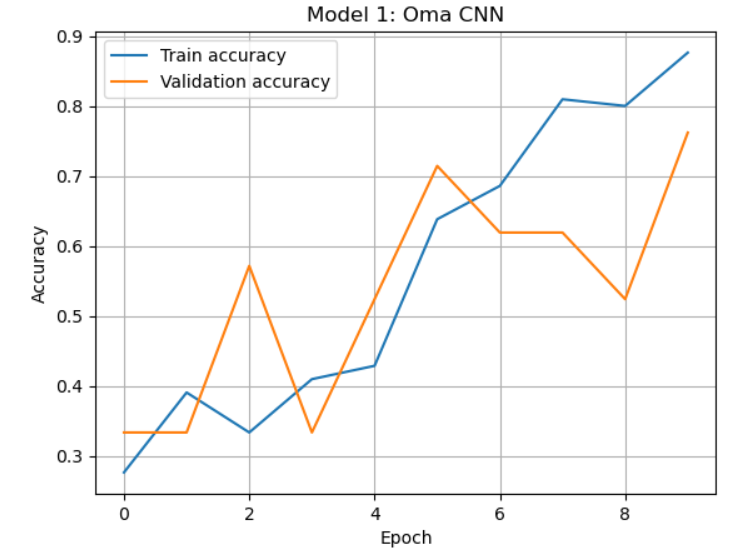

---

## 3. Malli 2: VGG16 feature extraction

Käytettiin ImageNetillä esikoulutettua VGG16-mallia.

VGG16:n konvoluutiokerrokset jäädytettiin ja niiden päälle lisättiin oma luokittelupää.

### Tulokset ja analyysi (VGG16 feature extraction)

Testitarkkuus: **83.3 %**

Tämä malli oli paras.

Se hyödyntää valmiiksi opittuja visuaalisia piirteitä kuten reunoja ja muotoja, mikä parantaa yleistyskykyä pienellä datasetillä.

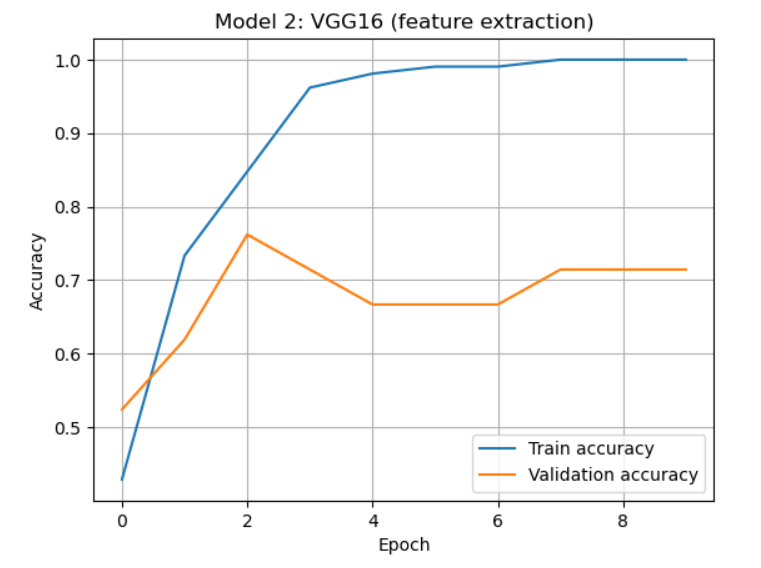

---

## 4. Malli 3: Fine-tuned VGG16

VGG16-mallin ylempiä kerroksia avattiin ja osaa verkosta koulutettiin uudelleen pienellä oppimisnopeudella.

### Tulokset ja analyysi (Fine-tuning)

Testitarkkuus: **45.8 %**

Suorituskyky heikkeni, koska datasetti oli liian pieni.

Malli alkoi ylisovittua ja menetti osan aiemmin oppimistaan yleisistä piirteistä.

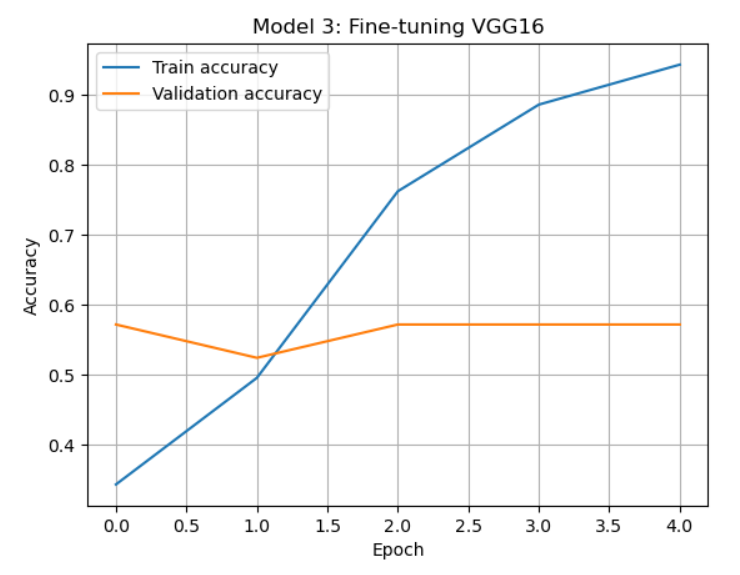

---

## 5. Mallien vertailu

| Malli | Testitarkkuus | Kommentti |
|------|--------------|----------|
| CNN | 70.8 % | Baseline, lievä overfitting |
| VGG16 feature extraction | 83.3 % | Paras suorituskyky |
| Fine-tuned VGG16 | 45.8 % | Ylisovittuminen pienellä datalla |

---

## 6. Väärin luokitellut kuvat

Virheitä esiintyi erityisesti:
- kun esineiden muodot muistuttivat toisiaan
- epätavallisissa kuvakulmissa
- monimutkaisissa taustoissa

Esimerkiksi kapeat mukit saatettiin sekoittaa pulloihin.

---

## 7. Haasteet ja ratkaisut

Suurin haaste oli datasetin pieni koko.

Ratkaisut:
- Data augmentation (kierto, zoom, peilaus)
- Transfer learning VGG16-mallilla

Nämä paransivat merkittävästi mallien suorituskykyä.

---

## 8. Pohdinta ja johtopäätökset

Tulokset osoittavat, että transfer learning on tehokkain ratkaisu pienillä dataseteillä.

Oma CNN toimii vertailupohjana, mutta VGG16 feature extraction antaa selvästi parhaan tuloksen.

Fine-tuning ei toimi hyvin ilman riittävää datamäärää.

### Keskeinen johtopäätös:
Transfer learning yhdistää valmiit visuaaliset piirteet ja uuden tehtävän luokittelun tehokkaimmin.